<a href="https://colab.research.google.com/github/kishor-cypto/projects/blob/main/Implementation_of_a_MobileNetV2_Based_Deep_Learning_Model_for_Binary_Skin_Cancer_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import random
random.seed(0)

import numpy as np
np.random.seed(0)

import tensorflow as tf
tf.random.set_seed(0)

import os
import json
import pandas as pd
from collections import Counter
from PIL import Image
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

In [14]:
cancer_train = "/content/drive/MyDrive/skin cancer binary classification dataset/Skin_Data/Cancer/Training"
cancer_test = "/content/drive/MyDrive/skin cancer binary classification dataset/Skin_Data/Cancer/Testing"

noncancer_train = "/content/drive/MyDrive/skin cancer binary classification dataset/Skin_Data/Non_Cancer/Training"
noncancer_test = "/content/drive/MyDrive/skin cancer binary classification dataset/Skin_Data/Non_Cancer/Testing"

In [15]:
train_files = []
train_labels = []

for file in os.listdir(cancer_train):
    train_files.append(os.path.join(cancer_train, file))
    train_labels.append("Cancer")

for file in os.listdir(noncancer_train):
    train_files.append(os.path.join(noncancer_train, file))
    train_labels.append("Non_Cancer")

train_df = pd.DataFrame({
    "filename": train_files,
    "class": train_labels
})

test_files = []
test_labels = []

for file in os.listdir(cancer_test):
    test_files.append(os.path.join(cancer_test, file))
    test_labels.append("Cancer")

for file in os.listdir(noncancer_test):
    test_files.append(os.path.join(noncancer_test, file))
    test_labels.append("Non_Cancer")

test_df = pd.DataFrame({
    "filename": test_files,
    "class": test_labels
})

print(train_df.head())
print(test_df.head())

                                            filename   class
0  /content/drive/MyDrive/skin cancer binary clas...  Cancer
1  /content/drive/MyDrive/skin cancer binary clas...  Cancer
2  /content/drive/MyDrive/skin cancer binary clas...  Cancer
3  /content/drive/MyDrive/skin cancer binary clas...  Cancer
4  /content/drive/MyDrive/skin cancer binary clas...  Cancer
                                            filename   class
0  /content/drive/MyDrive/skin cancer binary clas...  Cancer
1  /content/drive/MyDrive/skin cancer binary clas...  Cancer
2  /content/drive/MyDrive/skin cancer binary clas...  Cancer
3  /content/drive/MyDrive/skin cancer binary clas...  Cancer
4  /content/drive/MyDrive/skin cancer binary clas...  Cancer


In [16]:
img_size = 224
batch_size = 32

epochs_initial = 10
epochs_finetune = 10

In [17]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filename",
    y_col="class",
    target_size=(224,224),
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=True
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filename",
    y_col="class",
    target_size=(224,224),
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

print(train_generator.class_indices)
print(Counter(train_generator.classes))


Found 84 validated image filenames belonging to 2 classes.
Found 204 validated image filenames belonging to 2 classes.
{'Cancer': 0, 'Non_Cancer': 1}
Counter({0: 42, 1: 42})


In [18]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(1.0), 1: np.float64(1.0)}


In [20]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(
    len(train_generator.class_indices),
    activation='softmax'
)(x)

model = Model(
    inputs=base_model.input,
    outputs=output
)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,619,074 (9.99 MB)

 Trainable params: 361,090 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [22]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [23]:
history = model.fit(
    train_generator,
    epochs=epochs_initial,
    validation_data=test_generator,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 75s 32s/step - accuracy: 0.5952 - loss: 1.1643 - val_accuracy: 0.7843 - val_loss: 0.4913
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 6s/step - accuracy: 0.4524 - loss: 1.3724 - val_accuracy: 0.7402 - val_loss: 0.5556
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 7s/step - accuracy: 0.5952 - loss: 0.9293 - val_accuracy: 0.5637 - val_loss: 0.6452
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 6s/step - accuracy: 0.6190 - loss: 0.8592 - val_accuracy: 0.5147 - val_loss: 0.7320
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 25s 12s/step - accuracy: 0.5000 - loss: 1.0610 - val_accuracy: 0.4755 - val_loss: 0.7702
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 6s/step - accuracy: 0.6190 - loss: 0.8127 - val_accuracy: 0.4951 - val_loss: 0.7544


In [24]:
for layer in base_model.layers[-30:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_finetune = model.fit(
    train_generator,
    epochs=epochs_finetune,
    validation_data=test_generator,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 31s 8s/step - accuracy: 0.5595 - loss: 0.8839 - val_accuracy: 0.7843 - val_loss: 0.4911
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 7s/step - accuracy: 0.5476 - loss: 0.9502 - val_accuracy: 0.7892 - val_loss: 0.4909
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 7s/step - accuracy: 0.5357 - loss: 0.8431 - val_accuracy: 0.7941 - val_loss: 0.4914
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 7s/step - accuracy: 0.5595 - loss: 0.8202 - val_accuracy: 0.7892 - val_loss: 0.4921
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 7s/step - accuracy: 0.5952 - loss: 0.8245 - val_accuracy: 0.7843 - val_loss: 0.4932
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 7s/step - accuracy: 0.5000 - loss: 0.8967 - val_accuracy: 0.7794 - val_loss: 0.4953
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 7s/step - accuracy: 0.6071 - loss: 0.7814 - val_accuracy: 0.7941 - val_loss: 0.4980


In [25]:
loss, accuracy = model.evaluate(test_generator)

print("Final Test Accuracy: {:.2f}%".format(accuracy*100))

7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.7892 - loss: 0.4909
Final Test Accuracy: 78.92%


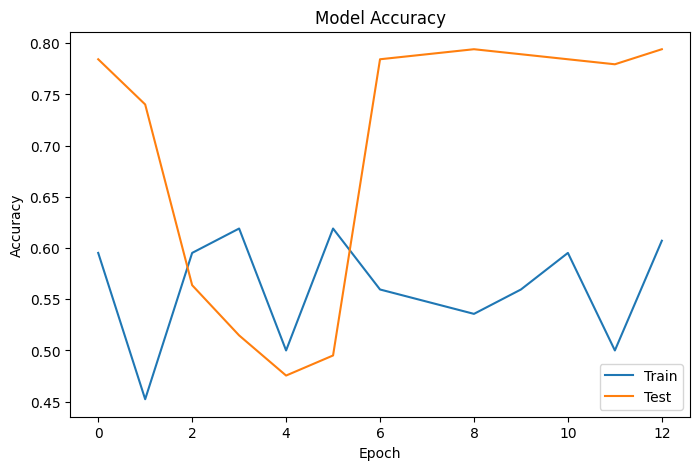

In [26]:
train_acc = history.history['accuracy'] + history_finetune.history['accuracy']
val_acc = history.history['val_accuracy'] + history_finetune.history['val_accuracy']

plt.figure(figsize=(8,5))
plt.plot(train_acc)
plt.plot(val_acc)
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Test"])
plt.show()

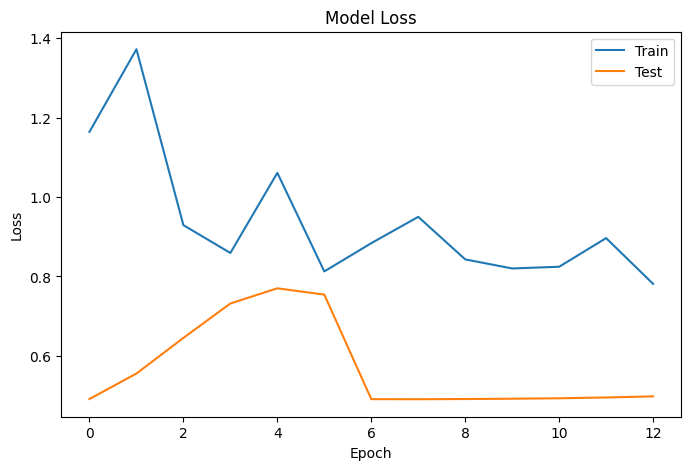

In [27]:
train_loss = history.history['loss'] + history_finetune.history['loss']
val_loss = history.history['val_loss'] + history_finetune.history['val_loss']

plt.figure(figsize=(8,5))
plt.plot(train_loss)
plt.plot(val_loss)
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Test"])
plt.show()

In [29]:
class_names = list(test_generator.class_indices.keys())

print("\nClassification Report")

print(
    classification_report(
        true_classes,
        pred_classes,
        target_names=class_names
    )
)


Classification Report
              precision    recall  f1-score   support

      Cancer       0.43      0.07      0.12        42
  Non_Cancer       0.80      0.98      0.88       162

    accuracy                           0.79       204
   macro avg       0.62      0.52      0.50       204
weighted avg       0.73      0.79      0.72       204



7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step


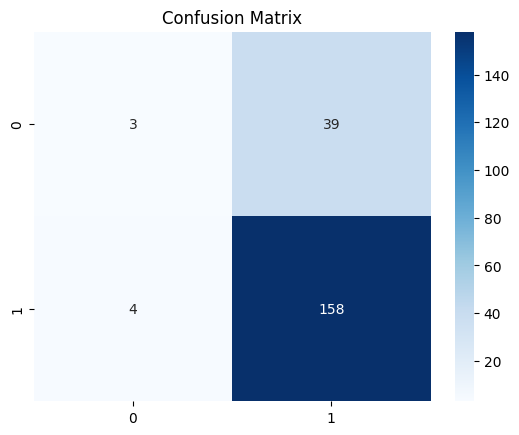

In [30]:
test_generator.reset()
pred = model.predict(test_generator)

y_pred = np.argmax(pred, axis=1)
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

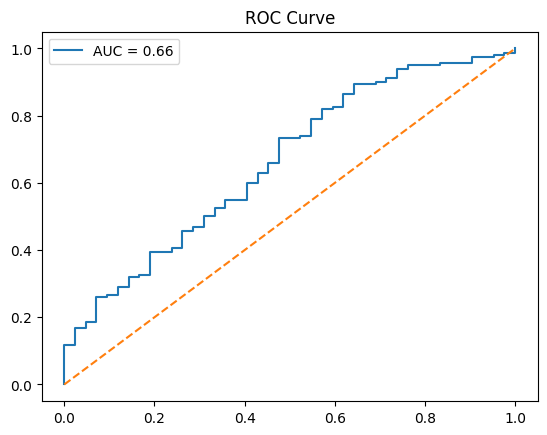

In [31]:
fpr, tpr, _ = roc_curve(y_true, pred[:,1])
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.legend()
plt.show()

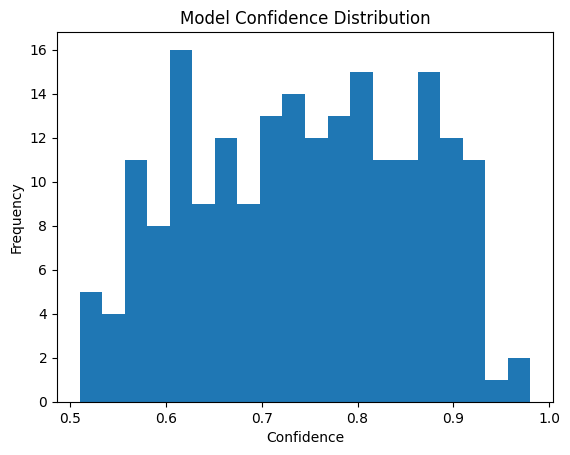

In [32]:
plt.hist(np.max(pred, axis=1), bins=20)
plt.title("Model Confidence Distribution")
plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.show()